# *RLSS 2026 - Multi-Armed Bandits Tutorial*

In this tutorial we code simple bandit environments and compare learning algorithms.

The main flow is:

## Part 1 — stochastic bandits

1. Build a Bernoulli bandit environment.
2. Build agents interacting with the environment.
3. Define and estimate cumulative pseudo-regret.
4. Implement a Greedy algorithm.
5. Implement the Explore-Then-Commit algorithm.
6. Implement the UCB1 algorithm.

## Part 2 — adversarial bandits

7. Build an oblivious adversarial bandit environment.
8. Define and compute adversarial regret.
7. Implement the EXP3 algorithm.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy.stats import beta as beta_dist
except ImportError:
    beta_dist = None

plt.rcParams["figure.figsize"] = (7, 4)

## **1. A stochastic bandit environment**

We start with a stochastic Multi-Armed Bandit with $K$ arms.

At each round $t$:

1. the agent chooses an arm $a_t \in \{0,\dots,K-1\}$;
2. the environment returns a reward $r_t(a_t)$;
3. the agent updates its statistics.

In this first part, rewards are Bernoulli:
$$
r_t(a) \sim \mathrm{Bernoulli}(p_a).
$$

In [2]:
class Environment:
    # Base class for bandit environments.
    def __init__(self):
        raise NotImplementedError

    def round(self, a_t):
        raise NotImplementedError

### Exercise 1 — complete the Bernoulli environment

Hints:

- `self.K` is the number of arms;
- `self.rewards` should be a matrix of shape `(T, K)`;
- `round(a_t)` should return the reward of arm `a_t` at current time `self.t`, then increase `self.t`.

In [3]:
class BernoulliEnvironment(Environment):
    def __init__(self, p, T):
        self.p = p
        self.K = len(p)
        self.T = T
        self.rewards = np.random.binomial(1,p,size=(T,self.K)) #...  # Hint: use np.random.binomial
        self.t = 0

    def round(self, a_t):
        rt = self.rewards[self.t,a_t]
        self.t += 1
        return rt

In [4]:
p = np.array([0.1, 0.5, 0.9])
K = len(p)
T = 100
seed = 17

np.random.seed(seed)
env = BernoulliEnvironment(p, T)

assert env.K == K
assert env.rewards.shape == (T, K)

r_t = env.round(0)
assert r_t in [0, 1]
assert env.t == 1

print("Environment works!")

Environment works!


## **2. Agents**

An agent needs three methods:

- `__init__`, to initialize the agent;
- `pull_arm`, to choose the next action;
- `update`, to incorporate the observed reward.

In [5]:
class Agent:
    # Base class for bandit agents.
    def __init__(self):
        raise NotImplementedError

    def pull_arm(self):
        raise NotImplementedError

    def update(self, r_t):
        raise NotImplementedError

### Exercise 2 — implement a random agent

The random agent samples all actions uniformly at random before the interaction starts.

In [6]:
class RandomAgent(Agent):
    def __init__(self, K, T):
        self.K = int(K)
        self.T = int(T)
        self.actions_sequence = np.random.choice(self.K,self.T) # Hint: use np.random.choice
        self.a_t = None
        self.action_history = np.array([], dtype=int)
        self.t = 0

    def pull_arm(self):
        a_t = self.actions_sequence[self.t]
        self.a_t = a_t
        return a_t

    def update(self, r_t):
        self.action_history = np.append(self.action_history,self.a_t)
        self.t += 1

In [7]:
np.random.seed(seed)
rand_agent = RandomAgent(K, T)

a_t = rand_agent.pull_arm()
assert a_t in [0, 1, 2]
rand_agent.update(1)
assert rand_agent.t == 1

print("RandomAgent works!")

RandomAgent works!


### A utility function to run one bandit trial

The following function runs one interaction between an environment and an agent.

Notice that we take the horizon from `env.T` rather than from a global variable. This makes the function safer to reuse.

In [13]:
def run_trial(env_type, agent_type, env_kwargs, agent_kwargs, seed=0):
    np.random.seed(seed)

    env = env_type(env_kwargs['p'],env_kwargs['T'])
    agent = agent_type(agent_kwargs['K'],env.T)

    T_trial = env.T
    rewards = np.zeros(T_trial)
    actions = np.zeros(T_trial, dtype=int)

    for t in range(T_trial):
        a_t = agent.pull_arm()
        r_t = env.round(a_t)
        agent.update(r_t)

        # logging
        rewards[t] = r_t
        actions[t] = a_t

    return rewards, actions, agent

In [11]:
len(p)

3

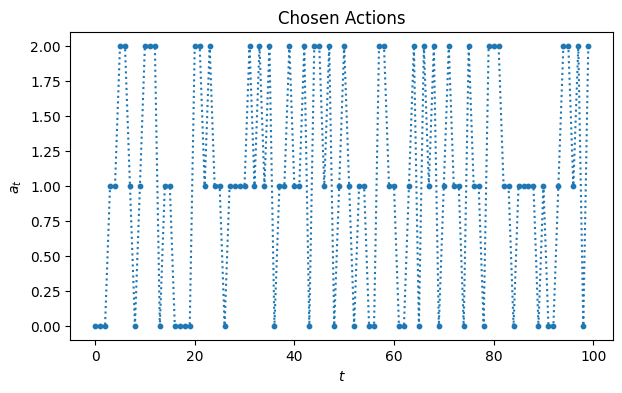

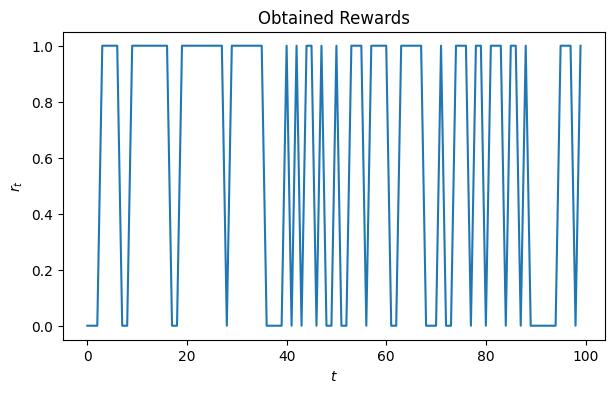

In [21]:
p = np.array([0.25, 0.5, 0.75])
K = len(p)
T = 100
seed = 17

env_type = BernoulliEnvironment
agent_type = RandomAgent

rewards, actions, rand_agent = run_trial(
    env_type,  # environment class
    agent_type,  # agent class
    env_kwargs={
        'p' : p,
        'T' : T
    },
    agent_kwargs={
        'K' : K
    },
    seed=seed,
)

# Plotting
plt.plot(actions, linestyle="dotted")
plt.scatter(np.arange(actions.shape[0]), actions, s=10)
plt.xlabel("$t$")
plt.ylabel("$a_t$")
plt.title("Chosen Actions")
plt.show()

plt.plot(rewards)
plt.xlabel("$t$")
plt.ylabel("$r_t$")
plt.title("Obtained Rewards")
plt.show()

## **3. Regret**

The best arm is
$
a^* \in \arg\max_a p_a.
$

The cumulative pseudo-regret is:
$$
R_T = \sum_{t=1}^T \left(p_{a^*} - p_{a_t}\right).
$$

In simulations we can compute it because we know the true vector `p`.

### Exercise 3 — complete the cumulative pseudo-regret function

In [22]:
rand_agent.action_history
rand_agent.update(1)


In [23]:
def cumulative_pseudo_regret(p, action_sequence):
    best_action = np.argmax(p)
    instantaneous_pseudo_regret = p[best_action] - p[action_sequence] 
    cumulative_regret = np.cumsum(instantaneous_pseudo_regret)
    return cumulative_regret

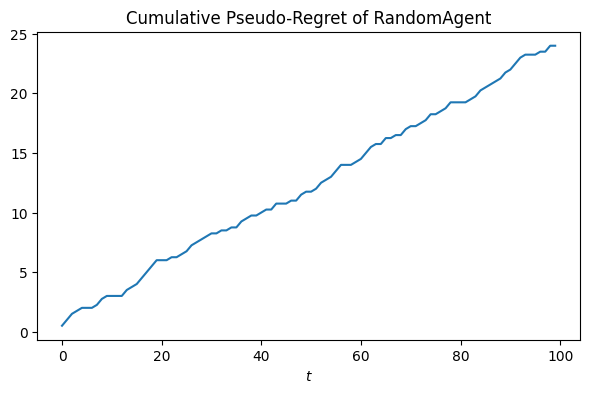

In [24]:
cum_regret = cumulative_pseudo_regret(p, actions)

plt.plot(cum_regret)
plt.xlabel("$t$")
plt.title("Cumulative Pseudo-Regret of RandomAgent")
plt.show()

### Estimating the average regret over multiple trials

Rewards are random, and the agent's decisions might be random as well. To evaluate an algorithm we average over multiple independent trials.

### Exercise 4 — complete the empirical evaluation function

In [28]:
def estimate_pseudo_regret(env_type, agent_type, env_kwargs, agent_kwargs, p, n_trials=30):
    regret_per_trial = []

    for seed in range(n_trials):
        _ , action , _ = run_trial(env_type, agent_type, env_kwargs, agent_kwargs, seed)

        cumulative_regret = cumulative_pseudo_regret(p,action)
        regret_per_trial.append(cumulative_regret)

    regret_per_trial = np.array(regret_per_trial)
    return regret_per_trial

In [29]:
def plot_average_regret(regret_per_trial, label=None, title="Cumulative Pseudo-Regret"):
    n_trials, T = regret_per_trial.shape

    average_regret = regret_per_trial.mean(axis=0)
    regret_sd = regret_per_trial.std(axis=0)
    standard_error = regret_sd / np.sqrt(n_trials)

    plt.plot(np.arange(T), average_regret, label=label)
    plt.fill_between(
        np.arange(T),
        average_regret - standard_error,
        average_regret + standard_error,
        alpha=0.3,
    )

    plt.xlabel("$t$")
    plt.title(title)
    if label is not None:
        plt.legend()

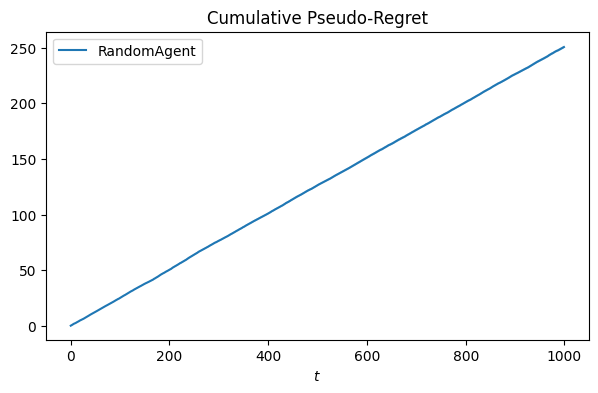

In [35]:
p = np.array([0.25, 0.5, 0.75])
K = len(p)
T = 1000
n_trials = 20

random_regret = estimate_pseudo_regret(
    env_type,  # environment class
    agent_type,  # agent class
    env_kwargs={
        'p' : p,
        'T' : T
    },
    agent_kwargs={
        'K' : K
    },
    p = p,
    n_trials = n_trials   
)
plot_average_regret(random_regret, label="RandomAgent")
plt.show()

In [27]:
random_regret.shape

(2, 1000)

## **4. Greedy algorithm**

The greedy algorithm always chooses the arm with the largest empirical mean.

To avoid division by zero, in the first $K$ rounds it pulls every arm once.

### Exercise 5 — implement the greedy agent

Update the empirical mean incrementally:
$$
\hat\mu_a \leftarrow \hat\mu_a + \frac{r_t-\hat\mu_a}{N_a}.
$$

In [ ]:
RandomAgent()

In [37]:
class GreedyAgent(Agent):
    def __init__(self, K, T):
        self.a_t = None
        self.K = int(K)
        self.T = int(T)
        self.action_history = np.array([], dtype=int)
        self.N_pulls = np.zeros(self.K)
        self.average_rewards = np.zeros(self.K)
        self.t = 0

    def pull_arm(self):
        if self.t < self.K:
            self.a_t = self.t
        else:
            self.a_t = np.argmax(self.average_rewards)
        return self.a_t

    def update(self, r_t):
        self.t += 1
        self.N_pulls[self.a_t] += 1
        self.average_rewards[self.a_t] += (r_t - self.average_rewards[self.a_t])/self.N_pulls[self.a_t] 

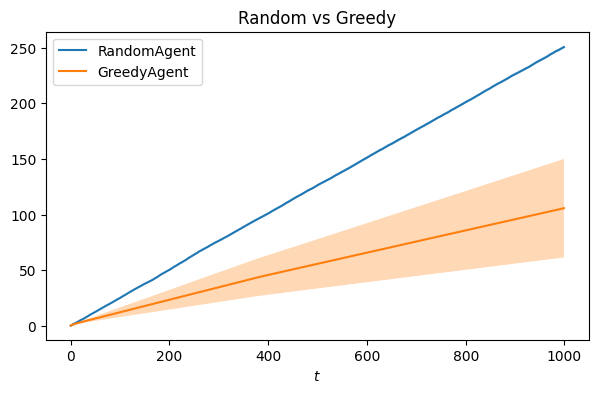

In [38]:
p = np.array([0.25, 0.5, 0.75])
K = len(p)
T = 1000
n_trials = 20

greedy_regret = estimate_pseudo_regret(
    env_type,  # environment class
    GreedyAgent,  # agent class
    env_kwargs={
        'p' : p,
        'T' : T
    },
    agent_kwargs={
        'K' : K
    },
    p = p,
    n_trials = n_trials   
)
plot_average_regret(random_regret, label="RandomAgent")
plot_average_regret(greedy_regret, label="GreedyAgent")
plt.title("Random vs Greedy")
plt.show()

### Discussion

Greedy can work well, but it can also stop exploring too early.

Try changing the instance below. What happens when two arms have very close means?

In [ ]:
p_hard = np.array([0.50, 0.52, 0.54])
K_hard = len(p_hard)
T = 2000
n_trials = 30

greedy_hard_regret = estimate_pseudo_regret(...)

plot_average_regret(greedy_hard_regret, label="GreedyAgent")
plt.title("Greedy on a harder instance")
plt.show()

## **5. Explore-Then-Commit**

Explore-Then-Commit (ETC) uses two phases:

1. **Exploration:** pull each arm `T0` times.
2. **Commitment:** play the empirical best arm forever.

### Exercise 6 — implement ETC

In [ ]:
class ETCAgent(Agent):
    def __init__(self, K, T, T0):
        self.K = int(K)
        self.T = int(T)
        self.T0 = int(T0)
        self.a_t = None
        self.average_rewards = np.zeros(self.K)
        self.N_pulls = np.zeros(self.K)
        self.t = 0

    def pull_arm(self):
        if ...:
            ...
        else:
            ...
        return self.a_t

    def update(self, r_t):
        ...

In [ ]:
p = np.array([0.25, 0.5, 0.75])
K = len(p)
T = 2000
n_trials = 20

T0 = int((T / K) ** (2 / 3) * np.log(T) ** (1 / 3)) # a good value according to theory

etc_regret = estimate_pseudo_regret(...)  # ETC

greedy_regret = estimate_pseudo_regret(...)  # Greedy

plot_average_regret(greedy_regret, label="GreedyAgent")
plot_average_regret(etc_regret, label="ETCAgent")
plt.title("Greedy vs ETC")
plt.show()

print(f"T0 = {T0}")

### Exercise — change `T0`

Try:

- very small `T0`;
- very large `T0`;
- the theoretical choice above.

What is the trade-off?

In [ ]:
T0_values = [1, 10, 50, 200]

for T0 in T0_values:
    etc_regret = estimate_pseudo_regret(...)

    plot_average_regret(etc_regret, label=f"T0={T0}")

plt.title("ETC with different exploration lengths")
plt.show()

## **6. UCB1**

UCB1 follows the principle of **optimism in the face of uncertainty**.

At time $t$, it chooses:
$$
a_t \in \arg\max_a \left\{ \hat\mu_a(t) + \sqrt{\frac{2\log T}{N_a(t)}} \right\}.
$$

The first term is exploitation. The second term is exploration.

### Exercise 7 — implement UCB1

In [ ]:
class UCB1Agent(Agent):
    def __init__(self, K, T, reward_range=1.0):
        self.K = int(K)
        self.T = int(T)
        self.reward_range = float(reward_range)
        self.a_t = None
        self.average_rewards = np.zeros(self.K)
        self.N_pulls = np.zeros(self.K)
        self.t = 0

    def pull_arm(self):
        if self.t < self.K:
            self.a_t = ...
        else:
            ...
        return self.a_t

    def update(self, r_t):
        ...

In [ ]:
p = np.array([0.25, 0.5, 0.75])
K = len(p)
T = 2000
n_trials = 20

ucb_regret = estimate_pseudo_regret(...)

etc_regret = estimate_pseudo_regret(...)

greedy_regret = estimate_pseudo_regret(...)

plot_average_regret(greedy_regret, label="Greedy")
plot_average_regret(etc_regret, label="ETC")
plot_average_regret(ucb_regret, label="UCB1")
plt.title("Greedy vs ETC vs UCB1")
plt.show()

### How many times does UCB1 pull each arm?

In [ ]:
rewards, actions, ucb_agent = run_trial(...)

plt.barh(y=[str(a) for a in range(K)], width=ucb_agent.N_pulls)
plt.xlabel("number of pulls")
plt.ylabel("arm")
plt.title("Number of pulls per arm of UCB1")
plt.show()

ucb_agent.N_pulls

### Visual representation of confidence intervals shrinking

The following plot shows the optimistic indices
$$
\hat\mu_a(t) + \sqrt{\frac{2\log T}{N_a(t)}}.
$$

At the beginning, confidence intervals are wide. As an arm is pulled more often, its confidence interval shrinks.

In [ ]:
p = np.array([0.25, 0.5, 0.75])
K = len(p)
T = 2000
seed = 17

np.random.seed(seed)
env = BernoulliEnvironment(p, T)
ucb_agent = UCB1Agent(K, T)

ci_widths = np.full((T, K), np.nan)
curr_average = np.zeros((T, K))
n_pulls = np.zeros(K)

for t in range(T):
    ...

    n_pulls[a_t] += 1

    pulled = n_pulls > 0
    ci_widths[t, pulled] = ...

    if t > 0:
        curr_average[t, :] = curr_average[t - 1, :]
    curr_average[t, a_t] += (r_t - curr_average[t, a_t]) / n_pulls[a_t]

for a in range(K):
    plt.plot(curr_average[:, a] + ci_widths[:, a], label=f"arm {a}")

plt.title("UCB indices")
plt.xlabel("$t$")
plt.ylim(0.75, 1.2)
plt.legend()
plt.show()

# **Part 2 — Adversarial Bandits**

In stochastic bandits, each arm has a fixed unknown distribution.

In adversarial bandits, we only assume that rewards are bounded:
$$
r_t(a) \in [0,1].
$$

A convenient model is the **oblivious adversary**: before the game starts, the adversary chooses a full reward table
$$
(r_t(a))_{t=1,\dots,T;\,a=1,\dots,K}.
$$

The learner only observes the reward of the chosen action.

## **7. An adversarial bandit environment**

In [ ]:
class AdversarialEnvironment(Environment):
    def __init__(self, rewards):
        rewards = np.asarray(rewards, dtype=float)

        self.rewards = ...
        self.T, self.K = ...
        self.t = ...

    def round(self, a_t):
        ...
        return ...

We now create a deterministic reward table chosen in advance by an oblivious adversary.

The rewards are **not i.i.d.**: they oscillate with time. Arm 2 is the best fixed arm in hindsight, and in fact it is also pointwise optimal at every time. However, the first few observations are deliberately misleading: greedy methods compare rewards observed at different times, so they can initially prefer a worse arm.

In [ ]:
def make_temporally_adversarial_rewards(T, K=5, gap=0.08):
    """Create a bounded, deterministic reward table.

    Arm 2 is the best fixed arm in hindsight. Rewards are time-dependent,
    so this is not a stochastic stationary bandit instance.
    """
    if K < 3:
        raise ValueError("This example is written for K >= 3.")

    t = np.arange(T)

    # A time-varying baseline. The first few values are chosen so that
    # the early samples can be misleading for greedy algorithms.
    base = np.where(((np.maximum(t - 3, 0) // 50) % 2) == 0, 0.95, 0.75)
    base[0] = 0.95
    base[1] = 0.95
    base[2] = 0.75

    rewards = np.zeros((T, K))

    # Arm 2 is always the best arm at each time.
    rewards[:, 2] = base

    # Arms 0 and 1 track the same temporal pattern but are worse.
    rewards[:, 0] = base - gap
    rewards[:, 1] = base - 0.15

    # Extra arms are weak distractors.
    if K > 3:
        rewards[:, 3] = 0.55
    if K > 4:
        rewards[:, 4:] = 0.40

    return rewards


T_adv = 2000
K_adv = 5
reward_matrix = make_temporally_adversarial_rewards(T_adv, K_adv)

plt.plot(np.cumsum(reward_matrix, axis=0))
plt.xlabel("$t$")
plt.ylabel("cumulative reward")
plt.title("Cumulative reward of each arm")
plt.legend([f"arm {a}" for a in range(K_adv)])
plt.show()

print("Best fixed arm in hindsight:", np.argmax(reward_matrix.sum(axis=0)))
print("Total reward of each arm:", np.round(reward_matrix.sum(axis=0), 2))

## **8. Adversarial regret**

In adversarial bandits, the standard comparator is the best fixed arm in hindsight:
$$
R_T = \max_a \sum_{t=1}^T r_t(a) - \sum_{t=1}^T r_t(a_t).
$$

For the plot below we compute the same quantity at every prefix $t$:
$$
R_t = \max_a \sum_{s=1}^t r_s(a) - \sum_{s=1}^t r_s(a_s).
$$

A subtle point: this regret is against a **fixed** arm, not against the best arm at each round. If the best arm changes over time, a learner that switches can even obtain negative fixed-comparator regret. That is not a coding bug, but it is confusing for a first tutorial. This example therefore keeps one arm pointwise optimal, so the curve is easier to interpret.

In [ ]:
def cumulative_adversarial_regret(reward_matrix, action_sequence):
    reward_matrix = np.asarray(reward_matrix, dtype=float)
    action_sequence = np.asarray(action_sequence, dtype=int)

    learner_rewards = ...
    learner_cumulative = ...

    arm_cumulative = ...
    best_fixed_cumulative = ...

    return ...


def estimate_adversarial_regret(agent_type, reward_matrix, agent_kwargs, n_trials=30):
    regret_per_trial = []

    for seed in range(n_trials):
        ...

    return np.array(regret_per_trial)

## **9. EXP3**

EXP3 is the classic algorithmic template for adversarial bandits.

It maintains positive weights $w_a(t)$ and samples arms according to
$$
q_a(t) = (1-\gamma)\frac{w_a(t)}{\sum_b w_b(t)} + \frac{\gamma}{K}.
$$

After observing only $r_t(a_t)$, it builds an importance-weighted estimate:
$$
\hat r_t(a) =
\begin{cases}
r_t(a_t)/q_{a_t}(t), & a=a_t,\\
0, & a\neq a_t.
\end{cases}
$$

Then it updates:
$$
w_a(t+1) = w_a(t)\exp\left(\frac{\gamma \hat r_t(a)}{K}\right).
$$

### Exercise 8 — implement EXP3

In [ ]:
class EXP3Agent(Agent):
    def __init__(self, K, T, gamma=None):
        self.K = int(K)
        self.T = int(T)

        if gamma is None:
            gamma = np.sqrt(self.K * np.log(self.K) / ((np.e - 1) * self.T))
            gamma = min(1.0, gamma)

        self.gamma = float(gamma)
        self.weights = np.ones(self.K)
        self.probabilities = np.ones(self.K) / self.K
        self.a_t = None
        self.t = 0

    def pull_arm(self):
        normalized_weights = ...
        self.probabilities = ...

        self.a_t = ...
        return self.a_t

    def update(self, r_t):
        estimated_rewards = ...
        estimated_rewards[self.a_t] = ...

        self.weights *= ...
        self.t += 1

In [ ]:
T_adv = 5000
K_adv = 5
reward_matrix = make_temporally_adversarial_rewards(T_adv, K_adv)
n_trials = 30

random_adv_regret = estimate_adversarial_regret(...)

greedy_adv_regret = estimate_adversarial_regret(...)

exp3_adv_regret = estimate_adversarial_regret(...)

plot_average_regret(random_adv_regret, label="Random")
plot_average_regret(greedy_adv_regret, label="Greedy")
plot_average_regret(exp3_adv_regret, label="EXP3")
plt.title("Adversarial regret to the best fixed arm")
plt.show()

### Discussion

- The reward table is deterministic and time-dependent, so it is not a stationary stochastic bandit instance.
- Random exploration is robust but wastes many pulls.
- Greedy and UCB1 were designed for stochastic environments. They can still work on some adversarial tables, but they do not come with adversarial guarantees.
- EXP3 explicitly randomizes and uses importance weighting. This is the key idea behind adversarial bandit algorithms.

**Important:** if you instead use a reward table where the best arm switches over time, the standard fixed-arm regret can become negative, because the learner may outperform every single fixed arm by switching. For such examples, use dynamic regret
$$
\sum_{t=1}^T \max_a r_t(a) - \sum_{t=1}^T r_t(a_t)
$$
or state clearly that the fixed-comparator regret is allowed to be negative.

# **Bonus exercises**

These are optional extensions for students who finish early or for a follow-up practical session.

1. **$\varepsilon$-greedy.** Implement an `EpsilonGreedyAgent` with either constant $\varepsilon$ or decaying $\varepsilon_t$. Compare it with Greedy and UCB1.
2. **Tuning EXP3.** Run EXP3 with several values of $\gamma$. How sensitive is performance to the exploration parameter?
3. **More arms.** Repeat the experiments with $K=10$ arms. What changes in the comparison between ETC and UCB1?
4. **Rewards in [0,M] for M>1 (e.g., sum of M Bernoulli).** What happens when the rewards are no longer contained in $[0,1]$? How would you adapt UCB1?
5. **Feedback Graphs**. Implement a feedback graph bandit environment and suitable algorithms.